In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Ambiente configurado! Versão do TensorFlow:", tf.__version__)

Ambiente configurado! Versão do TensorFlow: 2.20.0


In [10]:

!pip install kagglehub

import kagglehub
import os
import shutil

print("Iniciando o download seguro via Kaggle.")
path = kagglehub.dataset_download("gpiosenka/coffee-bean-dataset-resized-224-x-224")
print("Path para os arquivos originais:", path)

base_dir = "coffee_data"
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

shutil.copytree(path, base_dir)
print("\nO dataset do Kaggle está pronto na pasta 'coffee_data'.")

print("Conteúdo encontrado:", os.listdir(base_dir))

Iniciando o download seguro via Kaggle.
Using Colab cache for faster access to the 'coffee-bean-dataset-resized-224-x-224' dataset.
Path para os arquivos originais: /kaggle/input/coffee-bean-dataset-resized-224-x-224

O dataset do Kaggle está pronto na pasta 'coffee_data'.
Conteúdo encontrado: ['Coffee Bean.csv', 'test', 'train']


In [11]:
TRAIN_DIR = "coffee_data/train"
TEST_DIR = "coffee_data/test"

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Carregando as imagens de Treino...")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

print("\nCarregando as imagens de Teste...")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

classes_detectadas = train_generator.class_indices
print(f"\n Classes detectadas pelo sistema: {list(classes_detectadas.keys())}")

Carregando as imagens de Treino...
Found 1200 images belonging to 4 classes.

Carregando as imagens de Teste...
Found 400 images belonging to 4 classes.

 Classes detectadas pelo sistema: ['Dark', 'Green', 'Light', 'Medium']


In [12]:
modelo_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

modelo_base.trainable = False

x = modelo_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)

saida = Dense(4, activation='softmax')(x)

model = Model(inputs=modelo_base.input, outputs=saida)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Estrutura da CNN criada com Fine-Tuning de forma bem-sucedida!")
print(f"Total de camadas no modelo: {len(model.layers)}")

Estrutura da CNN criada com Fine-Tuning de forma bem-sucedida!
Total de camadas no modelo: 157


In [13]:
import time

print("Iniciando o treinamento do modelo... Aguarde.")
inicio = time.time()

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

fim = time.time()
print(f"\n🎯 Treinamento concluído com sucesso em {(fim - inicio):.2f} segundos!")

Iniciando o treinamento do modelo... Aguarde.
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 34s 444ms/step - accuracy: 0.8617 - loss: 0.3913 - val_accuracy: 0.9875 - val_loss: 0.0755
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.9800 - loss: 0.0764 - val_accuracy: 0.9900 - val_loss: 0.0526
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.9858 - loss: 0.0506 - val_accuracy: 0.9925 - val_loss: 0.0293
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.9933 - loss: 0.0346 - val_accuracy: 0.9975 - val_loss: 0.0199
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.9958 - loss: 0.0231 - val_accuracy: 0.9975 - val_loss: 0.0143
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.9975 - loss: 0.0184 - val_accuracy: 0.9975 - val_loss: 0.0125
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.9975 - loss: 0.0152 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - acc

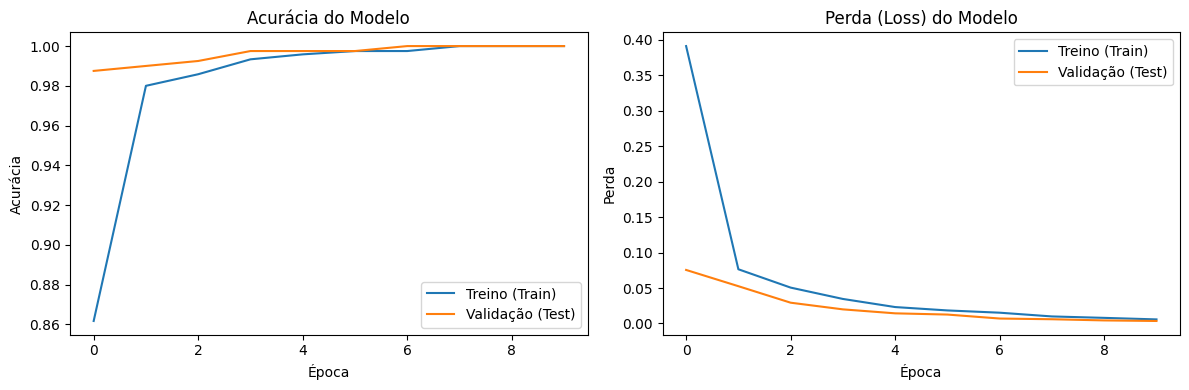

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino (Train)')
plt.plot(history.history['val_accuracy'], label='Validação (Test)')
plt.title('Acurácia do Modelo')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino (Train)')
plt.plot(history.history['val_loss'], label='Validação (Test)')
plt.title('Perda (Loss) do Modelo')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()

plt.tight_layout()
plt.show()

Calculando as previsões do modelo para a pasta de teste...
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step

================ RELATÓRIO DE CLASSIFICAÇÃO ================
              precision    recall  f1-score   support

        Dark       1.00      1.00      1.00       100
       Green       1.00      1.00      1.00       100
       Light       1.00      1.00      1.00       100
      Medium       1.00      1.00      1.00       100

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



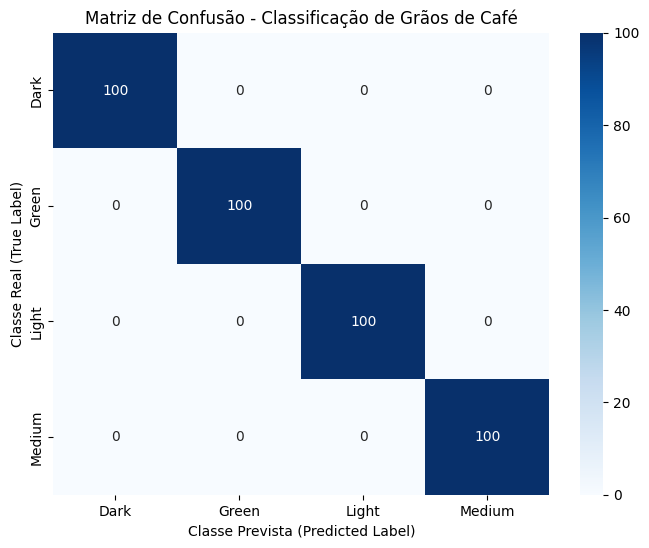

In [15]:

print("Calculando as previsões do modelo para a pasta de teste...")
predicoes = model.predict(test_generator)
y_pred = np.argmax(predicoes, axis=1)
y_true = test_generator.classes

nomes_classes = list(test_generator.class_indices.keys())

print("\n================ RELATÓRIO DE CLASSIFICAÇÃO ================")
print(classification_report(y_true, y_pred, target_names=nomes_classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão - Classificação de Grãos de Café')
plt.ylabel('Classe Real (True Label)')
plt.xlabel('Classe Prevista (Predicted Label)')
plt.show()